In [65]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [66]:
df=pd.read_csv('flo_data_20k.csv')

In [67]:
df.head()

,master_id,order_channel,last_order_channel,first_order_date,last_order_date,last_order_date_online,last_order_date_offline,order_num_total_ever_online,order_num_total_ever_offline,customer_value_total_ever_offline,customer_value_total_ever_online,interested_in_categories_12
0,cc294636-19f0-11eb-8d74-000d3a38a36f,Android App,Offline,2020-10-30,2021-02-26,2021-02-21,2021-02-26,4.0,1.0,139.99,799.38,[KADIN]
1,f431bd5a-ab7b-11e9-a2fc-000d3a38a36f,Android App,Mobile,2017-02-08,2021-02-16,2021-02-16,2020-01-10,19.0,2.0,159.97,1853.58,"[ERKEK, COCUK, KADIN, AKTIFSPOR]"
2,69b69676-1a40-11ea-941b-000d3a38a36f,Android App,Android App,2019-11-27,2020-11-27,2020-11-27,2019-12-01,3.0,2.0,189.97,395.35,"[ERKEK, KADIN]"
3,1854e56c-491f-11eb-806e-000d3a38a36f,Android App,Android App,2021-01-06,2021-01-17,2021-01-17,2021-01-06,1.0,1.0,39.99,81.98,"[AKTIFCOCUK, COCUK]"
4,d6ea1074-f1f5-11e9-9346-000d3a38a36f,Desktop,Desktop,2019-08-03,2021-03-07,2021-03-07,2019-08-03,1.0,1.0,49.99,159.99,[AKTIFSPOR]


In [68]:
df.shape

(19945, 12)

In [69]:
df.columns

Index(['master_id', 'order_channel', 'last_order_channel', 'first_order_date',
       'last_order_date', 'last_order_date_online', 'last_order_date_offline',
       'order_num_total_ever_online', 'order_num_total_ever_offline',
       'customer_value_total_ever_offline', 'customer_value_total_ever_online',
       'interested_in_categories_12'],
      dtype='object')

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19945 entries, 0 to 19944
Data columns (total 12 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   master_id                          19945 non-null  object 
 1   order_channel                      19945 non-null  object 
 2   last_order_channel                 19945 non-null  object 
 3   first_order_date                   19945 non-null  object 
 4   last_order_date                    19945 non-null  object 
 5   last_order_date_online             19945 non-null  object 
 6   last_order_date_offline            19945 non-null  object 
 7   order_num_total_ever_online        19945 non-null  float64
 8   order_num_total_ever_offline       19945 non-null  float64
 9   customer_value_total_ever_offline  19945 non-null  float64
 10  customer_value_total_ever_online   19945 non-null  float64
 11  interested_in_categories_12        19945 non-null  obj

In [71]:
df.describe()

,order_num_total_ever_online,order_num_total_ever_offline,customer_value_total_ever_offline,customer_value_total_ever_online
count,19945.000000,19945.000000,19945.000000,19945.000000
mean,3.110855,1.913913,253.922597,497.321690
std,4.225647,2.062880,301.532853,832.601886
min,1.000000,1.000000,10.000000,12.990000
25%,1.000000,1.000000,99.990000,149.980000
50%,2.000000,1.000000,179.980000,286.460000
75%,4.000000,2.000000,319.970000,578.440000
max,200.000000,109.000000,18119.140000,45220.130000


In [72]:
df.isnull().sum()

master_id                            0
order_channel                        0
last_order_channel                   0
first_order_date                     0
last_order_date                      0
last_order_date_online               0
last_order_date_offline              0
order_num_total_ever_online          0
order_num_total_ever_offline         0
customer_value_total_ever_offline    0
customer_value_total_ever_online     0
interested_in_categories_12          0
dtype: int64

In [73]:
df.duplicated().sum()

np.int64(0)

In [74]:
cat=['order_channel','last_order_channel']
num=[ 'order_num_total_ever_online', 'order_num_total_ever_offline',
       'customer_value_total_ever_offline', 'customer_value_total_ever_online']

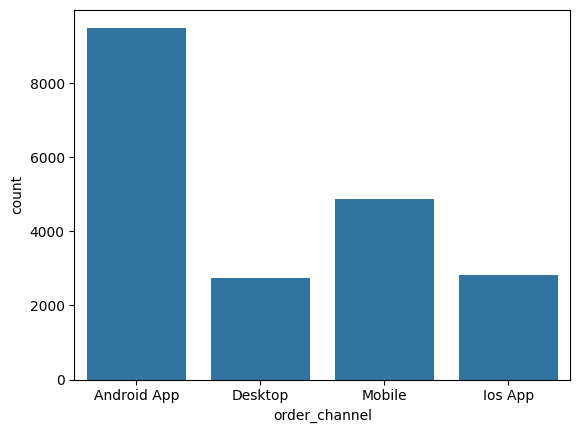

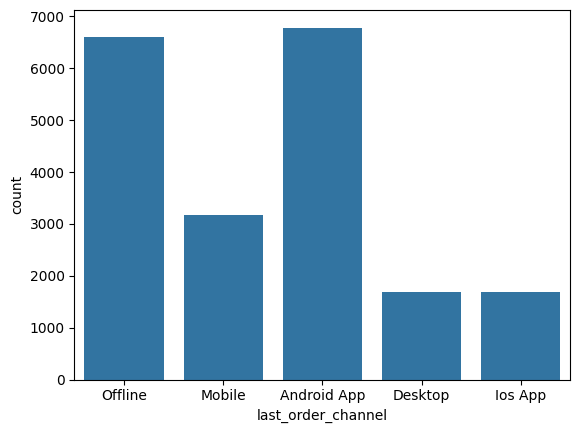

In [75]:
for i in cat:
    sns.countplot(x=df[i])
    plt.show()

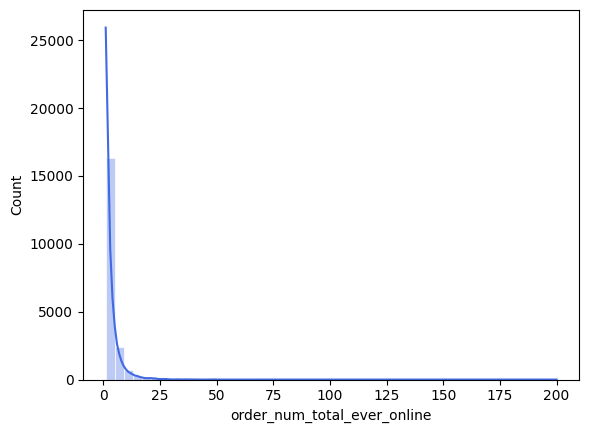

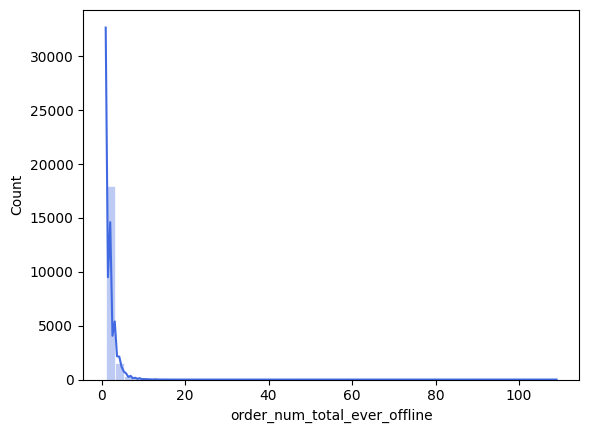

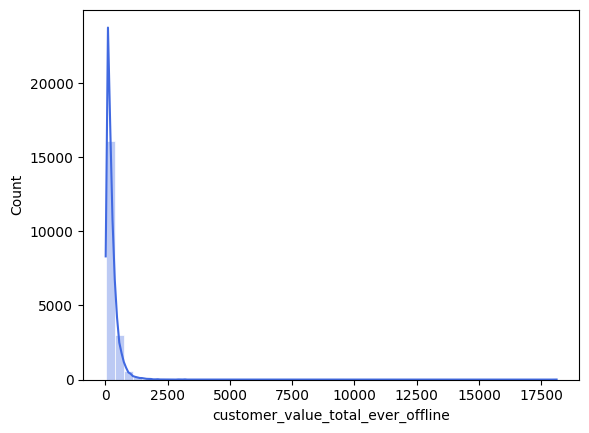

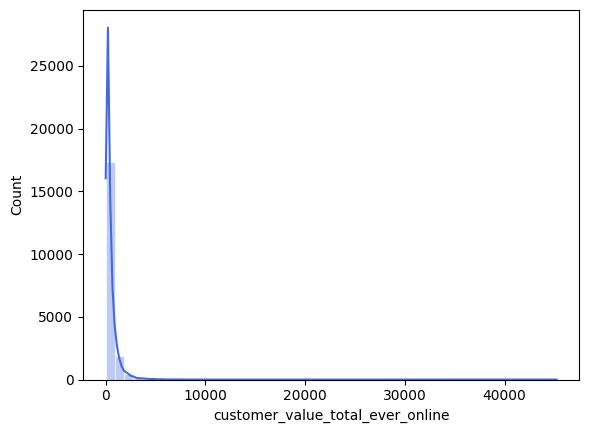

In [76]:
for i in num:
    sns.histplot(x=df[i], 
    bins=50,
    kde=True,
    color="royalblue",
    alpha=0.35,
    edgecolor="white",
    linewidth=0.5)
    plt.show()

In [77]:
date_cols = {
    "first_order_date": [
        "first_order_year",
        "first_order_month",
        "first_order_day"
    ],
    "last_order_date": [
        "last_order_year",
        "last_order_month",
        "last_order_day"
    ],
    "last_order_date_online": [
        "last_order_online_year",
        "last_order_online_month",
        "last_order_online_day"
    ],
    "last_order_date_offline": [
        "last_order_offline_year",
        "last_order_offline_month",
        "last_order_offline_day"
    ]
}

for col, scol in date_cols.items():
    df[col] = pd.to_datetime(df[col])

    df[scol[0]] = df[col].dt.year
    df[scol[1]] = df[col].dt.month
    df[scol[2]] = df[col].dt.day

In [78]:
df

,master_id,order_channel,last_order_channel,first_order_date,last_order_date,last_order_date_online,last_order_date_offline,order_num_total_ever_online,order_num_total_ever_offline,customer_value_total_ever_offline,...,first_order_day,last_order_year,last_order_month,last_order_day,last_order_online_year,last_order_online_month,last_order_online_day,last_order_offline_year,last_order_offline_month,last_order_offline_day
0,cc294636-19f0-11eb-8d74-000d3a38a36f,Android App,Offline,2020-10-30,2021-02-26,2021-02-21,2021-02-26,4.0,1.0,139.99,...,30,2021,2,26,2021,2,21,2021,2,26
1,f431bd5a-ab7b-11e9-a2fc-000d3a38a36f,Android App,Mobile,2017-02-08,2021-02-16,2021-02-16,2020-01-10,19.0,2.0,159.97,...,8,2021,2,16,2021,2,16,2020,1,10
2,69b69676-1a40-11ea-941b-000d3a38a36f,Android App,Android App,2019-11-27,2020-11-27,2020-11-27,2019-12-01,3.0,2.0,189.97,...,27,2020,11,27,2020,11,27,2019,12,1
3,1854e56c-491f-11eb-806e-000d3a38a36f,Android App,Android App,2021-01-06,2021-01-17,2021-01-17,2021-01-06,1.0,1.0,39.99,...,6,2021,1,17,2021,1,17,2021,1,6
4,d6ea1074-f1f5-11e9-9346-000d3a38a36f,Desktop,Desktop,2019-08-03,2021-03-07,2021-03-07,2019-08-03,1.0,1.0,49.99,...,3,2021,3,7,2021,3,7,2019,8,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19940,727e2b6e-ddd4-11e9-a848-000d3a38a36f,Android App,Offline,2019-09-21,2020-07-05,2020-06-05,2020-07-05,1.0,2.0,289.98,...,21,2020,7,5,2020,6,5,2020,7,5
19941,25cd53d4-61bf-11ea-8dd8-000d3a38a36f,Desktop,Desktop,2020-03-01,2020-12-22,2020-12-22,2020-03-01,1.0,1.0,150.48,...,1,2020,12,22,2020,12,22,2020,3,1
19942,8aea4c2a-d6fc-11e9-93bc-000d3a38a36f,Ios App,Ios App,2019-09-11,2021-05-24,2021-05-24,2019-09-11,2.0,1.0,139.98,...,11,2021,5,24,2021,5,24,2019,9,11
19943,e50bb46c-ff30-11e9-a5e8-000d3a38a36f,Android App,Android App,2019-03-27,2021-02-13,2021-02-13,2021-01-08,1.0,5.0,711.79,...,27,2021,2,13,2021,2,13,2021,1,8


In [79]:
df.drop(['first_order_date','last_order_date','last_order_date_online','last_order_date_offline','master_id'],axis=1,inplace=True,)

In [80]:
df

,order_channel,last_order_channel,order_num_total_ever_online,order_num_total_ever_offline,customer_value_total_ever_offline,customer_value_total_ever_online,interested_in_categories_12,first_order_year,first_order_month,first_order_day,last_order_year,last_order_month,last_order_day,last_order_online_year,last_order_online_month,last_order_online_day,last_order_offline_year,last_order_offline_month,last_order_offline_day
0,Android App,Offline,4.0,1.0,139.99,799.38,[KADIN],2020,10,30,2021,2,26,2021,2,21,2021,2,26
1,Android App,Mobile,19.0,2.0,159.97,1853.58,"[ERKEK, COCUK, KADIN, AKTIFSPOR]",2017,2,8,2021,2,16,2021,2,16,2020,1,10
2,Android App,Android App,3.0,2.0,189.97,395.35,"[ERKEK, KADIN]",2019,11,27,2020,11,27,2020,11,27,2019,12,1
3,Android App,Android App,1.0,1.0,39.99,81.98,"[AKTIFCOCUK, COCUK]",2021,1,6,2021,1,17,2021,1,17,2021,1,6
4,Desktop,Desktop,1.0,1.0,49.99,159.99,[AKTIFSPOR],2019,8,3,2021,3,7,2021,3,7,2019,8,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19940,Android App,Offline,1.0,2.0,289.98,111.98,"[ERKEK, AKTIFSPOR]",2019,9,21,2020,7,5,2020,6,5,2020,7,5
19941,Desktop,Desktop,1.0,1.0,150.48,239.99,[AKTIFSPOR],2020,3,1,2020,12,22,2020,12,22,2020,3,1
19942,Ios App,Ios App,2.0,1.0,139.98,492.96,[AKTIFSPOR],2019,9,11,2021,5,24,2021,5,24,2019,9,11
19943,Android App,Android App,1.0,5.0,711.79,297.98,"[ERKEK, AKTIFSPOR]",2019,3,27,2021,2,13,2021,2,13,2021,1,8


In [81]:
df["interested_in_categories_12"].value_counts()

interested_in_categories_12
[AKTIFSPOR]                                     3464
[KADIN]                                         2158
[]                                              2135
[ERKEK]                                         1973
[KADIN, AKTIFSPOR]                              1352
[ERKEK, AKTIFSPOR]                              1178
[ERKEK, KADIN]                                   848
[COCUK]                                          836
[ERKEK, KADIN, AKTIFSPOR]                        775
[AKTIFCOCUK]                                     679
[COCUK, KADIN]                                   443
[AKTIFCOCUK, COCUK]                              349
[COCUK, AKTIFSPOR]                               317
[AKTIFCOCUK, AKTIFSPOR]                          317
[COCUK, KADIN, AKTIFSPOR]                        241
[AKTIFCOCUK, ERKEK, COCUK, KADIN, AKTIFSPOR]     223
[ERKEK, COCUK]                                   215
[AKTIFCOCUK, COCUK, KADIN]                       213
[ERKEK, COCUK, KAD

In [82]:
df["interested_in_categories_12"] = (
    df["interested_in_categories_12"]
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
)

In [83]:
df

,order_channel,last_order_channel,order_num_total_ever_online,order_num_total_ever_offline,customer_value_total_ever_offline,customer_value_total_ever_online,interested_in_categories_12,first_order_year,first_order_month,first_order_day,last_order_year,last_order_month,last_order_day,last_order_online_year,last_order_online_month,last_order_online_day,last_order_offline_year,last_order_offline_month,last_order_offline_day
0,Android App,Offline,4.0,1.0,139.99,799.38,KADIN,2020,10,30,2021,2,26,2021,2,21,2021,2,26
1,Android App,Mobile,19.0,2.0,159.97,1853.58,"ERKEK, COCUK, KADIN, AKTIFSPOR",2017,2,8,2021,2,16,2021,2,16,2020,1,10
2,Android App,Android App,3.0,2.0,189.97,395.35,"ERKEK, KADIN",2019,11,27,2020,11,27,2020,11,27,2019,12,1
3,Android App,Android App,1.0,1.0,39.99,81.98,"AKTIFCOCUK, COCUK",2021,1,6,2021,1,17,2021,1,17,2021,1,6
4,Desktop,Desktop,1.0,1.0,49.99,159.99,AKTIFSPOR,2019,8,3,2021,3,7,2021,3,7,2019,8,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19940,Android App,Offline,1.0,2.0,289.98,111.98,"ERKEK, AKTIFSPOR",2019,9,21,2020,7,5,2020,6,5,2020,7,5
19941,Desktop,Desktop,1.0,1.0,150.48,239.99,AKTIFSPOR,2020,3,1,2020,12,22,2020,12,22,2020,3,1
19942,Ios App,Ios App,2.0,1.0,139.98,492.96,AKTIFSPOR,2019,9,11,2021,5,24,2021,5,24,2019,9,11
19943,Android App,Android App,1.0,5.0,711.79,297.98,"ERKEK, AKTIFSPOR",2019,3,27,2021,2,13,2021,2,13,2021,1,8


In [84]:
categories = df["interested_in_categories_12"].str.get_dummies(sep=", ")


In [85]:
df = pd.concat([df, categories], axis=1)

In [86]:
df.drop("interested_in_categories_12", axis=1, inplace=True)

In [87]:
df

,order_channel,last_order_channel,order_num_total_ever_online,order_num_total_ever_offline,customer_value_total_ever_offline,customer_value_total_ever_online,first_order_year,first_order_month,first_order_day,last_order_year,...,last_order_online_month,last_order_online_day,last_order_offline_year,last_order_offline_month,last_order_offline_day,AKTIFCOCUK,AKTIFSPOR,COCUK,ERKEK,KADIN
0,Android App,Offline,4.0,1.0,139.99,799.38,2020,10,30,2021,...,2,21,2021,2,26,0,0,0,0,1
1,Android App,Mobile,19.0,2.0,159.97,1853.58,2017,2,8,2021,...,2,16,2020,1,10,0,1,1,1,1
2,Android App,Android App,3.0,2.0,189.97,395.35,2019,11,27,2020,...,11,27,2019,12,1,0,0,0,1,1
3,Android App,Android App,1.0,1.0,39.99,81.98,2021,1,6,2021,...,1,17,2021,1,6,1,0,1,0,0
4,Desktop,Desktop,1.0,1.0,49.99,159.99,2019,8,3,2021,...,3,7,2019,8,3,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19940,Android App,Offline,1.0,2.0,289.98,111.98,2019,9,21,2020,...,6,5,2020,7,5,0,1,0,1,0
19941,Desktop,Desktop,1.0,1.0,150.48,239.99,2020,3,1,2020,...,12,22,2020,3,1,0,1,0,0,0
19942,Ios App,Ios App,2.0,1.0,139.98,492.96,2019,9,11,2021,...,5,24,2019,9,11,0,1,0,0,0
19943,Android App,Android App,1.0,5.0,711.79,297.98,2019,3,27,2021,...,2,13,2021,1,8,0,1,0,1,0


In [88]:
df = pd.get_dummies(
    df,
    columns=["order_channel", "last_order_channel"],
    dtype=int
)

In [92]:
df.columns



Index(['order_num_total_ever_online', 'order_num_total_ever_offline',
       'customer_value_total_ever_offline', 'customer_value_total_ever_online',
       'first_order_year', 'first_order_month', 'first_order_day',
       'last_order_year', 'last_order_month', 'last_order_day',
       'last_order_online_year', 'last_order_online_month',
       'last_order_online_day', 'last_order_offline_year',
       'last_order_offline_month', 'last_order_offline_day', 'AKTIFCOCUK',
       'AKTIFSPOR', 'COCUK', 'ERKEK', 'KADIN', 'order_channel_Android App',
       'order_channel_Desktop', 'order_channel_Ios App',
       'order_channel_Mobile', 'last_order_channel_Android App',
       'last_order_channel_Desktop', 'last_order_channel_Ios App',
       'last_order_channel_Mobile', 'last_order_channel_Offline'],
      dtype='object')

In [93]:
features = ['order_num_total_ever_online', 'order_num_total_ever_offline',
       'customer_value_total_ever_offline', 'customer_value_total_ever_online',
       'first_order_year', 'first_order_month', 'first_order_day',
       'last_order_year', 'last_order_month', 'last_order_day',
       'last_order_online_year', 'last_order_online_month',
       'last_order_online_day', 'last_order_offline_year',
       'last_order_offline_month', 'last_order_offline_day', 'AKTIFCOCUK',
       'AKTIFSPOR', 'COCUK', 'ERKEK', 'KADIN', 'order_channel_Android App',
       'order_channel_Desktop', 'order_channel_Ios App',
       'order_channel_Mobile', 'last_order_channel_Android App',
       'last_order_channel_Desktop', 'last_order_channel_Ios App',
       'last_order_channel_Mobile', 'last_order_channel_Offline']

X = df[features]

In [94]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [95]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

df["Cluster"] = kmeans.fit_predict(X_scaled)

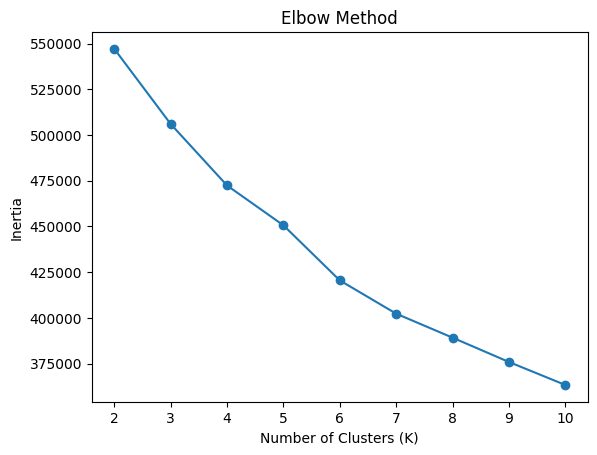

In [98]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2, 11), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [97]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

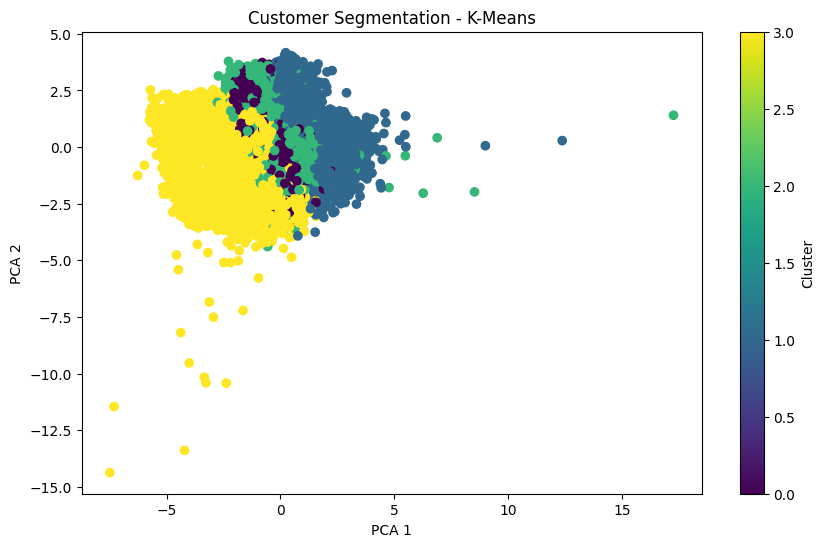

In [101]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df["Cluster"],
    cmap="viridis"
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Customer Segmentation - K-Means")

plt.colorbar(label="Cluster")

plt.show()

In [102]:
import joblib

joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(features, "features.pkl")

['features.pkl']

In [104]:
cluster_summary = df.groupby("Cluster")[features].mean()
cluster_summary

,order_num_total_ever_online,order_num_total_ever_offline,customer_value_total_ever_offline,customer_value_total_ever_online,first_order_year,first_order_month,first_order_day,last_order_year,last_order_month,last_order_day,...,KADIN,order_channel_Android App,order_channel_Desktop,order_channel_Ios App,order_channel_Mobile,last_order_channel_Android App,last_order_channel_Desktop,last_order_channel_Ios App,last_order_channel_Mobile,last_order_channel_Offline
Cluster,,,,,,,,,,,,,,,,,,,,,
0,2.780657,1.609039,203.904921,429.654200,2018.899494,6.463970,15.739254,2020.645070,5.789507,15.792035,...,0.334703,0.093236,0.000000,0.032238,0.874526,0.000000,0.00000,0.000000,1.000000,0.000000
1,3.785683,1.736338,215.072681,615.382127,2018.937546,6.617764,15.953307,2020.652232,5.665783,15.983355,...,0.342318,0.980262,0.000000,0.019738,0.000000,0.998969,0.00000,0.000000,0.000736,0.000295
2,3.702806,1.665583,221.197524,654.835625,2018.753028,6.625111,15.899261,2020.606499,5.847563,16.163959,...,0.333235,0.055539,0.354505,0.518168,0.071787,0.000000,0.49808,0.500739,0.000591,0.000591
3,2.272287,2.369608,334.561674,327.714147,2018.388679,6.527320,15.851067,2020.567277,5.608597,16.110792,...,0.467988,0.356743,0.232329,0.127592,0.283336,0.000151,0.00000,0.000151,0.000151,0.999546


In [105]:
cluster_names = {
    0: "High Value Customers",
    1: "Low Value Customers",
    2: "Frequent Customers",
    3: "Occasional Customers"
}

In [106]:
import joblib

joblib.dump(cluster_names, "cluster_names.pkl")

['cluster_names.pkl']